# PRÁCTICA 4: Entrenamiento, Evaluación y Despliegue.   
## Modelo de Generación de Texto con Despliegue en la Nube

Este notebook cubre el:
1. **Entrenamiento** en GPU (Colab)
2. **Evaluación** (perplejidad + generación)
3. **Descarga** de los archivos generados (modelo, tokenizer, resultados)
                   
DESARROLLADO POR: José A. Rodríguez López

FECHA: 27 de Marzo, 2026

PROYECTO: Programación de Inteligencia Artificial

## 1. Configurar el Entorno en Colab

In [ ]:
import os # Para manejar rutas y directorios
import sys # Para verificar la versión de Python y el entorno

print(f"Python version: {sys.version}") # Verificar la versión de Python
print(f"Current directory: {os.getcwd()}") # Verificar el directorio actual

# Verificar si estamos en Colab
try:
    import google.colab
    IN_COLAB = True
    print("Ejecutando en Google Colab")
except ImportError:
    IN_COLAB = False
    print("No estamos en Google Colab")

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Current directory: /content
Ejecutando en Google Colab


## 2. Instalar y Verificar Dependencias

In [ ]:
!pip install -q tensorflow numpy fastapi uvicorn pydantic slowapi python-dotenv httpx matplotlib nest_asyncio pyngrok boto3 # Instalar dependencias necesarias para el proyecto

In [ ]:
import tensorflow as tf # Librería principal para Deep Learning
import numpy as np # Librería para manejo de arrays y operaciones matemáticas
import matplotlib # Librería para visualización de datos

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)

# Verificar GPU
print("\nGPU disponible:", tf.config.list_physical_devices('GPU'))
if tf.config.list_physical_devices('GPU'):
    print("Activa en Colab: Entorno de ejecución > Cambiar tipo de entorno > GPU")
else:
    print("No hay GPU activa. El entrenamiento irá más lento.")

TensorFlow: 2.19.0
NumPy: 2.0.2
Matplotlib: 3.10.0

GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Activa en Colab: Entorno de ejecución > Cambiar tipo de entorno > GPU


## 3. Cargar Archivo de Corpus desde AWS S3

El corpus se descarga desde `s3://rodriguez-cloud-proyectos-ia/Practica_4/` y se guarda localmente como **data/corpus.txt**.

El bucket es privado, por lo que las credenciales AWS son obligatorias. Ejecutar primero la celda siguiente para cargar `AWS_ACCESS_KEY_ID` y `AWS_SECRET_ACCESS_KEY`.

In [ ]:
import os # Librería para manejar variables de entorno
from getpass import getpass # Librería para ingresar contraseñas de forma segura

print("Configurar credenciales AWS para acceder a un bucket S3 privado")

# Solicitar al usuario que ingrese sus credenciales AWS de forma segura
aws_access_key_id = getpass("AWS_ACCESS_KEY_ID: ").strip()
aws_secret_access_key = getpass("AWS_SECRET_ACCESS_KEY: ").strip()
aws_default_region = input("AWS_DEFAULT_REGION [us-east-1]: ").strip() or "us-east-1"

# Validar que se hayan ingresado las credenciales
if not aws_access_key_id or not aws_secret_access_key:
    raise ValueError("AWS_ACCESS_KEY_ID y AWS_SECRET_ACCESS_KEY son obligatorios para este bucket privado.")

# Cargar las credenciales en variables de entorno para que boto3 pueda usarlas
os.environ["AWS_ACCESS_KEY_ID"] = aws_access_key_id
os.environ["AWS_SECRET_ACCESS_KEY"] = aws_secret_access_key
os.environ["AWS_DEFAULT_REGION"] = aws_default_region

print("Credenciales AWS cargadas en variables de entorno para esta sesión del notebook")

Configurar credenciales AWS para acceder a un bucket S3 privado
AWS_ACCESS_KEY_ID: ··········
AWS_SECRET_ACCESS_KEY: ··········
AWS_DEFAULT_REGION [us-east-1]: 
Credenciales AWS cargadas en variables de entorno para esta sesión del notebook


In [ ]:
import os # Librería para manejar rutas y directorios
import boto3 # Librería para interactuar con AWS S3
from botocore.exceptions import BotoCoreError, ClientError, NoCredentialsError, PartialCredentialsError # Excepciones específicas de boto3
from pathlib import Path # Librería para manejar rutas de archivos

# Configuración del bucket S3 y rutas locales
BUCKET_NAME = "rodriguez-cloud-proyectos-ia"
PREFIX = "Practica_4/"
LOCAL_CORPUS_PATH = Path("data/corpus.txt")
REQUIRED_ENV_VARS = ["AWS_ACCESS_KEY_ID", "AWS_SECRET_ACCESS_KEY"]
NOMBRE_ARCHIVO_CORPUS = "corpus.txt"

# Construir la clave completa del objeto en S3 (incluyendo prefijo)
prefix_clean = PREFIX.strip("/")
S3_OBJECT_KEY = f"{prefix_clean}/{NOMBRE_ARCHIVO_CORPUS}" if prefix_clean else NOMBRE_ARCHIVO_CORPUS

# Validar que las variables de entorno necesarias estén presentes
missing_vars = [name for name in REQUIRED_ENV_VARS if not os.getenv(name, "").strip()]
if missing_vars:
    raise EnvironmentError(
        "Faltan credenciales AWS obligatorias. Ejecuta primero la celda anterior. "
        f"Variables faltantes: {', '.join(missing_vars)}"
    )

# Crear directorios locales si no existen
LOCAL_CORPUS_PATH.parent.mkdir(parents=True, exist_ok=True)
Path("output").mkdir(parents=True, exist_ok=True)

# Inicializar el cliente S3 con las credenciales cargadas en variables de entorno
s3_client = boto3.client("s3", region_name=os.getenv("AWS_DEFAULT_REGION", "us-east-1"))

# Descargar el corpus desde S3
try:
    # Descargar el archivo del corpus desde S3 a la ruta local especificada
    s3_client.download_file(BUCKET_NAME, S3_OBJECT_KEY, str(LOCAL_CORPUS_PATH))
except (NoCredentialsError, PartialCredentialsError):
    raise RuntimeError(
        "Las credenciales AWS no están completas o no son válidas. "
        "Vuelve a ejecutar la celda anterior con claves correctas."
    )
except ClientError as exc:
    error_code = exc.response.get("Error", {}).get("Code", "")
    if error_code in {"404", "NoSuchKey", "NotFound"}:
        # Mostrar pistas rápidas para encontrar la ruta correcta
        candidates = []
        try:
            response = s3_client.list_objects_v2(Bucket=BUCKET_NAME, Prefix=prefix_clean + "/", MaxKeys=10)
            candidates = [obj["Key"] for obj in response.get("Contents", [])]
        except Exception:
            pass

        detalle = [
            f"No se encontró el objeto: s3://{BUCKET_NAME}/{S3_OBJECT_KEY}",
            "Verifica el nombre del archivo y el prefijo en S3.",
        ]
        if candidates:
            detalle.append("Ejemplos de claves disponibles bajo ese prefijo:")
            detalle.extend([f"- {key}" for key in candidates])

        raise RuntimeError("\n".join(detalle)) from exc

    raise RuntimeError(
        "No fue posible acceder al bucket privado en S3. "
        f"Detalle: {exc}"
    ) from exc
except BotoCoreError as exc:
    raise RuntimeError(
        "No fue posible acceder al bucket privado en S3. "
        f"Detalle: {exc}"
    ) from exc

# Mostrar información básica del corpus descargado
print(f"Corpus descargado desde s3://{BUCKET_NAME}/{S3_OBJECT_KEY}")
print(f"Guardado en: {LOCAL_CORPUS_PATH}")

size_mb = LOCAL_CORPUS_PATH.stat().st_size / (1024 * 1024)
print(f"Tamaño: {size_mb:.2f} MB")

# Leer y mostrar las primeras líneas del corpus para verificar su contenido
with LOCAL_CORPUS_PATH.open("r", encoding="utf-8", errors="ignore") as file_handle:
    lines = []
    for _ in range(5):
        line = file_handle.readline()
        if not line:
            break
        lines.append(line)

print("\nPrimeras líneas del corpus:")
print("".join(lines))

Corpus descargado desde s3://rodriguez-cloud-proyectos-ia/Practica_4/corpus.txt
Guardado en: data/corpus.txt
Tamaño: 96.96 MB

Primeras líneas del corpus:
10 Herramientas de Inteligencia Artificial conversacionales
Ahora te dejaremos una pequeña lista de herramientas de inteligencia artificial conversacionales más usadas en la actualidad. En su mayoría están basadas en ChatGPT o en GPT; lo que requiere el uso de prompts para interactuar con las mismas, sin embargo, están orientadas a varios tipos de utilidades. A continuación te las mencionamos:
Ariana AI: bot de ChatGPT diseñado para ser utilizado en WhatsApp, Ariana está diseñada específicamente para ayudarte con las tareas diarias.
Bing Chat: Herramienta de inteligencia artificial conversacional desarrollada por Microsoft, basada en GPT-4. Ésta aplicación te permite conversar con una inteligencia artificial que puede responder a tus consultas de búsqueda, ayudarte a crear contenido y ofrecerte sugerencias personalizadas.
CharacterAI

## 4. Crear archivos del Proyecto

Crear los archivos Python necesarios en Colab.

In [ ]:
%%writefile model.py
# -*- coding: utf-8 -*-
"""
                 PRÁCTICA 4: Entrenamiento, Evaluación y Despliegue.
                         Script principal para la práctica 4
                       Programación de Inteligencia Artificial

Modelo de lenguaje para la práctica 4.

DESARROLLADO POR:   José A. Rodríguez López
FECHA: 27 de Marzo, 2026
PROYECTO: Programación de Inteligencia Artificial
================================================================================
"""

import tensorflow as tf # Librería principal para Deep Learning
from tensorflow.keras import layers, Model # Librería para construir modelos con Keras
import json # Librería para manejar archivos en formato JSON

class LMConfig:
    """Configuración del modelo de lenguaje."""

    def __init__(
        self,
        vocab_size=10000, # Tamaño del vocabulario (número de tokens únicos)
        embedding_dim=384, # Dimensión de los vectores de embedding para cada token
        lstm_units=640, # Número de unidades en cada capa
        num_lstm_layers=3, # Número de capas en el modelo
        dropout_rate=0.25, # Tasa de dropout para regularización
        sequence_length=50, # Longitud de las secuencias de entrada para el modelo
    ):
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.lstm_units = lstm_units
        self.num_lstm_layers = num_lstm_layers
        self.dropout_rate = dropout_rate
        self.sequence_length = sequence_length

    # Métodos para guardar y cargar la configuración en formato JSON
    def save(self, path: str):
        with open(path, "w", encoding="utf-8") as f:
            json.dump(self.__dict__, f, indent=2)

    # Cargar la configuración desde un archivo JSON
    @classmethod
    def load(cls, path: str):
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)
        return cls(**data)

# Funciones para construir y compilar el modelo de lenguaje
def build_language_model(config: LMConfig) -> Model:
    """Construye un modelo de lenguaje LSTM multi-capa."""
    inputs = layers.Input(shape=(config.sequence_length,), name="token_ids")

    # Capa de embedding para convertir IDs de tokens en vectores densos
    x = layers.Embedding(
        input_dim=config.vocab_size,
        output_dim=config.embedding_dim,
        mask_zero=True,
        name="embedding",
    )(inputs)

    # Mantener secuencia completa para predecir el siguiente token en cada paso.
    for i in range(config.num_lstm_layers):
        x = layers.LSTM(
            units=config.lstm_units,
            return_sequences=True,
            dropout=config.dropout_rate,
            recurrent_dropout=0.0,
            name=f"lstm_{i + 1}",
        )(x)
        if i < config.num_lstm_layers - 1:
            x = layers.LayerNormalization(name=f"layer_norm_{i + 1}")(x)

    # Capa de salida con softmax para predecir la probabilidad de cada token en el vocabulario
    x = layers.Dropout(config.dropout_rate, name="output_dropout")(x)
    outputs = layers.Dense(config.vocab_size, activation="softmax", name="output_probs")(x)

    # Crear el modelo Keras con las entradas y salidas definidas
    model = Model(inputs=inputs, outputs=outputs, name="LSTMLanguageModel")
    return model


def compile_model(model: Model, learning_rate: float = 5e-4) -> Model:
    """Compila el modelo."""
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

Overwriting model.py


In [ ]:
%%writefile train_utils.py
# -*- coding: utf-8 -*-
"""
                 PRÁCTICA 4: Entrenamiento, Evaluación y Despliegue.
                         Script principal para la práctica 4
                       Programación de Inteligencia Artificial

Modelo de lenguaje para la práctica 4.

DESARROLLADO POR:   José A. Rodríguez López
FECHA: 27 de Marzo, 2026
PROYECTO: Programación de Inteligencia Artificial
================================================================================
"""

import json # Librería para manejar archivos en formato JSON
from collections import Counter # Librería para contar la frecuencia de palabras
import tensorflow as tf # Librería principal para Deep Learning
import numpy as np # Librería para manejo de arrays y operaciones matemáticas

class TextTokenizer:
    """Tokenizador a nivel de palabra."""
    # Definir tokens especiales para el vocabulario
    PAD, UNK, BOS, EOS = "<PAD>", "<UNK>", "<BOS>", "<EOS>"

    # Inicializar el tokenizador con un tamaño de vocabulario máximo
    def __init__(self, vocab_size: int = 10000):
        self.vocab_size = vocab_size
        self.word2idx = {}
        self.idx2word = {}

    def fit(self, text: str):
        """Construye el vocabulario."""
        words = text.lower().split()
        freq = Counter(words)
        specials = [self.PAD, self.UNK, self.BOS, self.EOS]
        vocab = specials + [w for w, _ in freq.most_common(self.vocab_size - len(specials))]
        self.word2idx = {w: i for i, w in enumerate(vocab)}
        self.idx2word = {i: w for w, i in self.word2idx.items()}
        print(f"Vocabulario construido: {len(self.word2idx)} tokens")

    def encode(self, text: str):
        """Convierte texto a IDs de tokens, usando UNK para palabras fuera del vocabulario."""
        unk = self.word2idx[self.UNK]
        return [self.word2idx.get(w, unk) for w in text.lower().split()]

    def decode(self, ids):
        """Convierte IDs de tokens a texto, usando UNK para tokens desconocidos."""
        return " ".join(self.idx2word.get(i, self.UNK) for i in ids)

    def save(self, path: str):
        """Guarda el tokenizador en un archivo JSON."""
        with open(path, "w", encoding="utf-8") as f:
            json.dump({"word2idx": self.word2idx, "idx2word": {str(k): v for k, v in self.idx2word.items()}}, f)

    @classmethod
    def load(cls, path: str):
        """Carga el tokenizador desde un archivo JSON."""
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)
        tok = cls()
        tok.word2idx = data["word2idx"]
        tok.idx2word = {int(k): v for k, v in data["idx2word"].items()}
        tok.vocab_size = len(tok.word2idx)
        return tok

def make_dataset(token_ids, seq_len, batch_size, shuffle=True):
    """Crea un tf.data.Dataset para entrenamiento."""
    total = tf.data.Dataset.from_tensor_slices(token_ids)
    sequences = total.batch(seq_len + 1, drop_remainder=True)

    def split_xy(seq):
        """Dado un tensor de forma (seq_len + 1,), devuelve (seq_len,) para X y (seq_len,) para Y."""
        return seq[:-1], seq[1:]

    # Aplicar la función de mapeo para dividir cada secuencia en entradas (X) y etiquetas (Y)
    ds = sequences.map(split_xy, num_parallel_calls=tf.data.AUTOTUNE)
    # Mezclar los datos si se especifica, con un buffer grande para asegurar buena aleatorización
    if shuffle:
        ds = ds.shuffle(buffer_size=10000)
    # Agrupar los datos en lotes de tamaño batch_size, descartando el último lote si no tiene el tamaño completo
    ds = ds.batch(batch_size, drop_remainder=True)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

Overwriting train_utils.py


## 5. Entrenar el Modelo

Funciones realizadas:
- separa entrenamiento, validación y prueba,
- guarda checkpoints periódicos,
- monitoriza la pérdida durante el entrenamiento,
- guarda el mejor modelo y el modelo final.

Usando corpus: data/corpus.txt
Corpus: 99381098 caracteres, ~15451938 palabras
Vocabulario construido: 15000 tokens
Tokens totales: 15451938
Train: 12361550, Val: 1545194, Test: 1545194

Resumen del modelo:


Model: "LSTMLanguageModel"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ token_ids           │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 64, 384)   │  5,760,000 │ token_ids[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 64)        │          0 │ token_ids[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64, 640)   │  2,624,000 │ embedding[0][0],  │
│                     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_norm_1        │ (None, 64, 640)   │      1,280 │ lstm_1[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 64, 640)   │  3,279,360 │ layer_norm_1[0][… │
│                     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_norm_2        │ (None, 64, 640)   │      1,280 │ lstm_2[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 64, 640)   │  3,279,360 │ layer_norm_2[0][… │
│                     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_dropout      │ (None, 64, 640)   │          0 │ lstm_3[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_probs        │ (None, 64, 15000) │  9,615,000 │ output_dropout[0… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,560,280 (93.69 MB)

 Trainable params: 24,560,280 (93.69 MB)

 Non-trainable params: 0 (0.00 B)

Preview y shape: (48, 64), output shape: (48, 64, 15000)

Iniciando entrenamiento...
Epoch 1/20
3962/3962 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.1587 - loss: 5.8082
Epoch 1: saving model to output/checkpoints/epoch_01.keras

Epoch 1: finished saving model to output/checkpoints/epoch_01.keras

Epoch 1: val_loss improved from None to 4.66744, saving model to output/best_model.keras

Epoch 1: finished saving model to output/best_model.keras
3962/3962 ━━━━━━━━━━━━━━━━━━━━ 934s 234ms/step - accuracy: 0.1963 - loss: 5.1667 - val_accuracy: 0.2227 - val_loss: 4.6674 - learning_rate: 5.0000e-04
Epoch 2/20
3962/3962 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.2373 - loss: 4.3891
Epoch 2: saving model to output/checkpoints/epoch_02.keras

Epoch 2: finished saving model to output/checkpoints/epoch_02.keras

Epoch 2: val_loss improved from 4.66744 to 4.37908, saving model to output/best_model.keras

Epoch 2: finished saving model to output/best_model.keras
3962/3962 ━━━━━━━━━━━━━━━━━

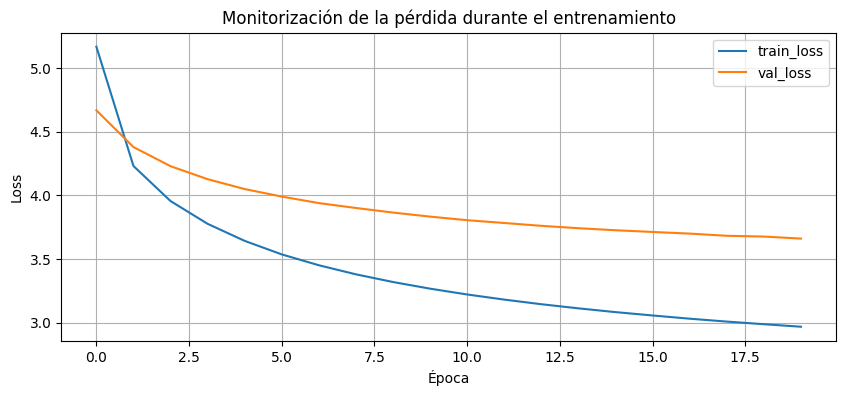

Loss final entrenamiento: 2.9685
Loss final validación: 3.6604


In [ ]:
import importlib # Librería para recargar módulos.
import model as model_module # Importar el módulo del modelo para poder recargarlo después de editarlo
from train_utils import TextTokenizer, make_dataset # Importar el tokenizador y la función para crear datasets
import tensorflow as tf # Librería principal para Deep Learning
import time # Librería para medir el tiempo de entrenamiento
import glob # Librería para buscar archivos en el sistema
import os # Librería para manejar rutas y directorios
import matplotlib.pyplot as plt # Librería para visualización de datos

# Evita usar una versión cacheada del módulo model.py en el kernel.
model_module = importlib.reload(model_module)
LMConfig = model_module.LMConfig
build_language_model = model_module.build_language_model
compile_model = model_module.compile_model

# Buscar archivos de corpus en la carpeta data y cargar.
corpus_files = glob.glob("data/*")
if not corpus_files:
    print("No hay archivo de corpus. Por favor, sube uno en la celda anterior.")
else:
    corpus_path = corpus_files[0]
    print(f"Usando corpus: {corpus_path}")

    with open(corpus_path, "r", encoding="utf-8", errors="ignore") as f:
        text = f.read()
    print(f"Corpus: {len(text)} caracteres, ~{len(text.split())} palabras")

    tokenizer = TextTokenizer(vocab_size=15000) # Crear el tokenizador con un vocabulario máximo de 15000 tokens
    tokenizer.fit(text) # Construir el vocabulario a partir del texto del corpus
    tokenizer.save("output/tokenizer.json") # Guardar el tokenizador

    token_ids = tokenizer.encode(text) # Convertir el texto del corpus a una lista de IDs de tokens
    print(f"Tokens totales: {len(token_ids)}") # Mostrar el número total de tokens en el corpus después de la tokenización

    # Dividir los datos en conjuntos de entrenamiento, validación y prueba (80% train, 10% val, 10% test)
    train_end = int(0.8 * len(token_ids))
    val_end = int(0.9 * len(token_ids))
    train_ids = token_ids[:train_end]
    val_ids = token_ids[train_end:val_end]
    test_ids = token_ids[val_end:]
    print(f"Train: {len(train_ids)}, Val: {len(val_ids)}, Test: {len(test_ids)}")

    # Crear datasets de TensorFlow para entrenamiento, validación y prueba
    seq_len = 64
    batch_size = 48
    train_ds = make_dataset(train_ids, seq_len, batch_size, shuffle=True)
    val_ds = make_dataset(val_ids, seq_len, batch_size, shuffle=False)
    test_ds = make_dataset(test_ids, seq_len, batch_size, shuffle=False)

    # Construir y compilar el modelo de lenguaje
    config = LMConfig(
        vocab_size=len(tokenizer.word2idx),
        embedding_dim=384,
        lstm_units=640,
        num_lstm_layers=3,
        dropout_rate=0.25,
        sequence_length=seq_len,
    )
    config.save("output/model_config.json")

    # Construir el modelo de lenguaje utilizando la configuración definida y compilarlo con una tasa de aprendizaje de 5e-4
    model = build_language_model(config)
    compile_model(model, learning_rate=5e-4)
    print("\nResumen del modelo:")
    model.summary()

    # Validación temprana de formas para evitar fallos en model.fit.
    x_preview, y_preview = next(iter(train_ds))
    yhat_preview = model(x_preview, training=False)
    print(f"Preview y shape: {y_preview.shape}, output shape: {yhat_preview.shape}")
    if len(yhat_preview.shape) != 3:
        raise ValueError(
            f"Salida inválida del modelo: {yhat_preview.shape}. Se esperaba (batch, seq_len, vocab_size)."
        )

    # Crear directorio para checkpoints si no existe
    os.makedirs("output/checkpoints", exist_ok=True)

    # Configurar callbacks para guardar checkpoints, reducir la tasa de aprendizaje y detener el entrenamiento temprano
    print("\nIniciando entrenamiento...")
    t0 = time.time()

    checkpoint_every_epoch = tf.keras.callbacks.ModelCheckpoint(
        filepath="output/checkpoints/epoch_{epoch:02d}.keras",
        save_best_only=False,
        save_freq="epoch",
        verbose=1,
    )
    best_model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
        filepath="output/best_model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    )
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-5,
        verbose=1,
    )
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        min_delta=1e-3,
        restore_best_weights=True,
        verbose=1,
    )

    # Entrenar el modelo utilizando los datasets de entrenamiento y validación, con los callbacks configurados para guardar checkpoints, reducir la tasa de aprendizaje y detener el entrenamiento temprano si no hay mejora en la validación.
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=20,
        callbacks=[checkpoint_every_epoch, best_model_checkpoint, reduce_lr, early_stop],
    )

    # Medir el tiempo de entrenamiento y mostrarlo en minutos
    elapsed = (time.time() - t0) / 60
    print(f"\nEntrenamiento completado en {elapsed:.1f} minutos")

    # Guardar el modelo final después del entrenamiento
    model.save("output/model_final.keras")
    print("Modelo guardado en output/model_final.keras")

    # Visualizar la pérdida de entrenamiento y validación a lo largo de las épocas
    plt.figure(figsize=(10, 4))
    plt.plot(history.history["loss"], label="train_loss")
    plt.plot(history.history["val_loss"], label="val_loss")
    plt.title("Monitorización de la pérdida durante el entrenamiento")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Mostrar la pérdida final de entrenamiento y validación después del último epoch
    if history.history.get("loss"):
        print(f"Loss final entrenamiento: {history.history['loss'][-1]:.4f}")
    if history.history.get("val_loss"):
        print(f"Loss final validación: {history.history['val_loss'][-1]:.4f}")

## 6. Evaluación y Generación de Texto

### 6.1 Evaluación cuantitativa con perplejidad sobre conjunto de prueba

La perplejidad mide cuán sorprendido está el modelo frente al siguiente token.
- Cuanto menor, mejor.
- Un valor cercano a 1 sería ideal.
- Se calcula sobre `test_ds`, no sobre entrenamiento ni validación.

In [ ]:
import math # Librería para operaciones matemáticas
from train_utils import TextTokenizer # Importar el tokenizador para cargarlo y usarlo en la evaluación

# Cargar el modelo final guardado después del entrenamiento y el tokenizador para evaluar el modelo en el conjunto de prueba
model = tf.keras.models.load_model("output/model_final.keras")
tokenizer = TextTokenizer.load("output/tokenizer.json")

def compute_perplexity(model, dataset):
    """Calcula la pérdida promedio y la perplexidad del modelo en el dataset dado."""
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False)
    total_loss = 0.0
    n_batches = 0

    for x_batch, y_batch in dataset:
        probs = model(x_batch, training=False)
        loss = loss_fn(y_batch, probs)
        total_loss += float(loss)
        n_batches += 1

    avg_loss = total_loss / max(n_batches, 1)
    return math.exp(avg_loss), avg_loss

# Evaluar el modelo en el conjunto de prueba y calcular la pérdida promedio y la perplexidad
ppl, avg_loss = compute_perplexity(model, test_ds)
print(f"\nLOSS MEDIA EN TEST: {avg_loss:.4f}")
print(f"PERPLEJIDAD EN TEST: {ppl:.2f}")

# Interpretar la perplexidad obtenida en el conjunto de prueba utilizando umbrales comunes para modelos de lenguaje
if ppl < 30:
    print("Interpretación: excelente")
elif ppl < 100:
    print("Interpretación: buena")
elif ppl < 300:
    print("Interpretación: aceptable")
else:
    print("Interpretación: el modelo necesita más entrenamiento o más datos")


LOSS MEDIA EN TEST: 3.7649
PERPLEJIDAD EN TEST: 43.16
Interpretación: buena


### 6.2 Generación de Texto (Métricas cualitativas)

Prueba 3 estrategias diferentes:
- Greedy search: siempre el token más probable.
- Sampling: más variado que greedy.
- Top-K sampling: limita a los K tokens más probables.

In [30]:
import numpy as np # Librería para manejo de arrays y operaciones matemáticas

def _next_token_probs(model, x, tokenizer, valid_pos=None):
    """Devuelve distribución del siguiente token y bloquea tokens especiales."""
    pred = model.predict(x, verbose=0)

    # Si la salida es (1, seq_len, vocab_size), tomar la posición válida para predecir el siguiente token.
    if pred.ndim == 3:
        if valid_pos is None:
            valid_pos = pred.shape[1] - 1
        valid_pos = max(0, min(int(valid_pos), pred.shape[1] - 1))
        probs = pred[0, valid_pos, :]
    else:
        probs = pred[0]

    # Evitar que aparezcan tokens especiales en la salida final.
    blocked = [
        tokenizer.word2idx.get(tokenizer.PAD),
        tokenizer.word2idx.get(tokenizer.UNK),
        tokenizer.word2idx.get(tokenizer.BOS),
    ]
    probs = probs.copy()
    for idx in blocked:
        if idx is not None and 0 <= idx < len(probs):
            probs[idx] = 0.0

    # Normalizar las probabilidades para que sumen 1, evitando divisiones por cero si todas las probabilidades son cero después de bloquear.
    total = probs.sum()
    if total <= 0:
        probs = np.ones_like(probs, dtype=np.float64)
        for idx in blocked:
            if idx is not None and 0 <= idx < len(probs):
                probs[idx] = 0.0
        probs /= probs.sum()
    else:
        probs = probs / total

    return probs

def _resolve_seq_len(model, seq_len=None):
    """Usa la longitud de entrada real del modelo si no se pasa una manualmente."""
    return int(seq_len) if seq_len is not None else int(model.input_shape[1])

def _ensure_seed_tokens(tokens, tokenizer):
    """Garantiza al menos un token para iniciar la generación."""
    if tokens:
        return tokens
    bos = tokenizer.word2idx.get(tokenizer.BOS)
    return [int(bos)] if bos is not None else [0]

def _build_model_input(tokens, seq_len):
    """Right padding para compatibilidad con máscaras en LSTM/CuDNN."""
    window = tokens[-seq_len:]
    valid_len = len(window)
    padded = window + [0] * (seq_len - valid_len)
    x = np.array([padded], dtype=np.int32)
    return x, valid_len - 1

def generate_greedy(model, tokenizer, seed, n_words=50, seq_len=None):
    """Greedy search: siempre el token más probable."""
    seq_len = _resolve_seq_len(model, seq_len)
    tokens = _ensure_seed_tokens(tokenizer.encode(seed), tokenizer)

    for _ in range(n_words):
        x, valid_pos = _build_model_input(tokens, seq_len)
        probs = _next_token_probs(model, x, tokenizer, valid_pos=valid_pos)
        next_token = int(np.argmax(probs))
        tokens.append(next_token)

    return tokenizer.decode(tokens)

def generate_sampling(model, tokenizer, seed, n_words=50, seq_len=None, temperature=1.0):
    """Sampling: más variado que greedy."""
    seq_len = _resolve_seq_len(model, seq_len)
    tokens = _ensure_seed_tokens(tokenizer.encode(seed), tokenizer)

    for _ in range(n_words):
        x, valid_pos = _build_model_input(tokens, seq_len)
        probs = _next_token_probs(model, x, tokenizer, valid_pos=valid_pos)
        log_probs = np.log(probs + 1e-10) / temperature
        log_probs -= log_probs.max()
        scaled_probs = np.exp(log_probs)
        scaled_probs /= scaled_probs.sum()
        next_token = int(np.random.choice(len(scaled_probs), p=scaled_probs))
        tokens.append(next_token)

    return tokenizer.decode(tokens)

def generate_top_k(model, tokenizer, seed, n_words=50, seq_len=None, k=40, temperature=0.8):
    """Top-K sampling: limita a los K tokens más probables."""
    seq_len = _resolve_seq_len(model, seq_len)
    tokens = _ensure_seed_tokens(tokenizer.encode(seed), tokenizer)

    for _ in range(n_words):
        x, valid_pos = _build_model_input(tokens, seq_len)
        probs = _next_token_probs(model, x, tokenizer, valid_pos=valid_pos)
        top_k_idx = np.argsort(probs)[-k:]
        top_k_probs = probs[top_k_idx]
        log_probs = np.log(top_k_probs + 1e-10) / temperature
        log_probs -= log_probs.max()
        scaled = np.exp(log_probs)
        scaled /= scaled.sum()
        next_token = int(np.random.choice(top_k_idx, p=scaled))
        tokens.append(next_token)

    return tokenizer.decode(tokens)

# Generar con diferentes estrategias
seed = "la inteligencia artificial"
print(f"SEED: '{seed}'")
print("=" * 70)

print("\nESTRATEGIA 1: Greedy (determinista)")
text1 = generate_greedy(model, tokenizer, seed, n_words=40)
print(text1[:150] + "...")

print("\nESTRATEGIA 2: Sampling (T=0.8, creativo)")
text2 = generate_sampling(model, tokenizer, seed, n_words=40, temperature=0.8)
print(text2[:150] + "...")

print("\nESTRATEGIA 3: Top-K (k=40, controlado)")
text3 = generate_top_k(model, tokenizer, seed, n_words=40, k=40, temperature=0.8)
print(text3[:150] + "...")

SEED: 'la inteligencia artificial'

ESTRATEGIA 1: Greedy (determinista)
la inteligencia artificial (ia) ha sido necesariamente adoptada aprovechando áreas de desarrollo tales como las matemáticas, la lógica simbólica, la s...

ESTRATEGIA 2: Sampling (T=0.8, creativo)
la inteligencia artificial y la psicología cognitiva que han integrado la teoría de la información y la acción de las entidades tales como la percepci...

ESTRATEGIA 3: Top-K (k=40, controlado)
la inteligencia artificial y las ciencias de la computación, la computación ubicua o la computación en la nube y los sistemas de computación distribui...


## 7. Descargar Archivos Generados

Descarga todos los ficheros generados (modelo, tokenizador, etc...) comprimidos en un ZIP a la carpeta **Descargas** del equipo local.

In [31]:
from google.colab import files # Librería para descargar archivos desde Colab al PC
import os # Librería para manejar rutas y directorios
import zipfile # Librería para crear archivos ZIP

# Archivos a incluir en la descarga
ficheros_a_descargar = [
    "output/model_final.keras",
    "output/best_model.keras",
    "output/tokenizer.json",
    "output/model_config.json",
    "model.py",
    "train_utils.py",
]

# Crear un archivo ZIP con los archivos listados para facilitar la descarga
zip_path = "practica4_archivos.zip"

print("Creando ZIP con los archivos generados...")
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for f in ficheros_a_descargar:
        if os.path.exists(f):
            zf.write(f)
            print(f"  Añadido: {f}")
        else:
            print(f"  No encontrado (omitido): {f}")

size_mb = os.path.getsize(zip_path) / (1024 * 1024)
print(f"\nZIP creado: {zip_path} ({size_mb:.2f} MB)")
print("Descargando a la carpeta Descargas del equipo...")
files.download(zip_path)
print("Descarga finalizada")

Creando ZIP con los archivos generados...
  Añadido: output/model_final.keras
  Añadido: output/best_model.keras
  Añadido: output/tokenizer.json
  Añadido: output/model_config.json
  Añadido: model.py
  Añadido: train_utils.py

ZIP creado: practica4_archivos.zip (519.97 MB)
Descargando a la carpeta Descargas del equipo...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descarga finalizada
